# Phase 1-2: 듀얼 벡터 분리 효과 검증

capability_text와 experience_text를 **분리 임베딩**하는 것이 **단일 합산 벡터**보다 실제로 나은지 정량 검증.

### 검증 항목
1. 단일 벡터(capability+experience 합산) vs 듀얼 벡터 검색 품질 비교
2. capability 검색 정밀도: 기술 스택 쿼리 → 해당 기술 보유자가 상위
3. experience 검색 정밀도: 도메인/경험 쿼리 → 해당 경험자가 상위
4. 가중치 조합별 최종 스코어 비교 (단일 vs 듀얼)

In [29]:
from _bootstrap import setup_project_path

setup_project_path()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


WindowsPath('C:/Users/mk.jang/Desktop/TLC/08_TSM/retrieval-lab')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from embedding_retrieval.config import RetrievalConfig
from embedding_retrieval.factory import create_embeddings
from embedding_retrieval.stores.dual_upstash import DualUpstashStore
from embedding_retrieval.scenarios.sample_data import SAMPLE_ENGINEER_PROFILES

config = RetrievalConfig.from_env()
embeddings = create_embeddings(config)
profiles = SAMPLE_ENGINEER_PROFILES

dual_store = DualUpstashStore(
    embeddings=embeddings,
    url=config.vector_store_kwargs["url"],
    token=config.vector_store_kwargs["token"],
)

def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

print(f"Provider: {config.embedding_provider} / {config.embedding_model}")
print(f"엔지니어 {len(profiles)}명 로드")
print("DualUpstashStore 초기화 완료")

## 1. 임베딩 준비 — 단일 벡터 vs 듀얼 벡터

- **단일 벡터**: capability_text + experience_text를 합쳐서 1개 임베딩
- **듀얼 벡터**: capability_text, experience_text 각각 임베딩

In [ ]:
# 단일 벡터: capability + experience 합산 텍스트 (새 포맷이므로 임베딩 필요)
combined_texts = [
    f"[기술스택]\n{p.capability_text}\n\n{p.experience_text}"
    for p in profiles
]
combined_vecs = np.array(embeddings.embed_documents(combined_texts))
combined_normed = combined_vecs / np.linalg.norm(combined_vecs, axis=1, keepdims=True)

# 듀얼 벡터: Upstash에서 fetch — 임베딩 API 재호출 없음
print("capability / experience 벡터 fetch 중...")
cap_vec_map = dual_store.fetch_cap_vectors()
exp_vec_map = dual_store.fetch_exp_vectors()

cap_vecs = np.array([cap_vec_map[p.engineer_id] for p in profiles])
exp_vecs = np.array([exp_vec_map[p.engineer_id] for p in profiles])
cap_normed = cap_vecs / np.linalg.norm(cap_vecs, axis=1, keepdims=True)
exp_normed = exp_vecs / np.linalg.norm(exp_vecs, axis=1, keepdims=True)

print(f"단일 벡터 shape: {combined_vecs.shape}")
print(f"capability 벡터 shape: {cap_vecs.shape}")
print(f"experience 벡터 shape: {exp_vecs.shape}")

## 2. 검색 시나리오 정의

Notion 스펙의 실제 검색 흐름을 반영한 테스트 케이스.
각 시나리오에 **기대 랭킹**(ground truth)을 설정하고 단일 vs 듀얼의 적중률을 비교.

In [32]:
scenarios = [
    {
        "name": "Java/Spring 백엔드 + 제조업 ERP 경험",
        "cap_query": "Java / Spring Boot",
        "exp_query": "[프로젝트] 현대차 ERP 시스템 개발: 제조업 ERP 시스템 재구축\n[포지션] 백엔드 개발자\n[기타요건] 현대차 프로젝트 경험 우대",
        "cap_weight": 0.6,
        "exp_weight": 0.4,
        "expected_top3": ["eng-001", "eng-002", "eng-005"],
    },
    {
        "name": "React 프론트엔드 + 차트 대시보드",
        "cap_query": "React / TypeScript / Chart.js",
        "exp_query": "[프로젝트] 판매 통계 대시보드: 실시간 차트 기반 모니터링 시스템\n[포지션] 프론트엔드 개발자\n[기타요건] 차트.js 경험 우대",
        "cap_weight": 0.7,
        "exp_weight": 0.3,
        "expected_top3": ["eng-003", "eng-004"],
    },
    {
        "name": "PL (경험 중심) + 제조업 리더십",
        "cap_query": "Java / Spring Boot",
        "exp_query": "[프로젝트] 현대차 ERP 시스템 개발: 제조업 ERP 시스템 재구축\n[포지션] PL\n[기타요건] 팀장 역할 필수, 대규모 프로젝트 리드 경험",
        "cap_weight": 0.2,
        "exp_weight": 0.8,
        "expected_top3": ["eng-001", "eng-002"],
    },
    {
        "name": "이커머스 물류 백엔드",
        "cap_query": "Python / FastAPI / Docker / Kubernetes",
        "exp_query": "[프로젝트] 이커머스 물류 최적화: 주문/배송 시스템 고도화\n[포지션] 백엔드 개발자\n[기타요건] 물류/주문 시스템 경험",
        "cap_weight": 0.5,
        "exp_weight": 0.5,
        "expected_top3": ["eng-005"],
    },
    {
        "name": "UX 디자이너 + 핀테크",
        "cap_query": "Figma / Adobe XD / Protopie",
        "exp_query": "[프로젝트] 금융 앱 UX 개선: 신규 금융 상품 가입 프로세스\n[포지션] UX 디자이너\n[기타요건] 핀테크 경험 우대",
        "cap_weight": 0.4,
        "exp_weight": 0.6,
        "expected_top3": ["des-001"],
    },
]

print(f"총 {len(scenarios)}개 시나리오 정의 완료")
for s in scenarios:
    print(f"  - {s['name']} (cap:{s['cap_weight']}, exp:{s['exp_weight']}) 기대: {s['expected_top3']}")

총 5개 시나리오 정의 완료
  - Java/Spring 백엔드 + 제조업 ERP 경험 (cap:0.6, exp:0.4) 기대: ['eng-001', 'eng-002', 'eng-005']
  - React 프론트엔드 + 차트 대시보드 (cap:0.7, exp:0.3) 기대: ['eng-003', 'eng-004']
  - PL (경험 중심) + 제조업 리더십 (cap:0.2, exp:0.8) 기대: ['eng-001', 'eng-002']
  - 이커머스 물류 백엔드 (cap:0.5, exp:0.5) 기대: ['eng-005']
  - UX 디자이너 + 핀테크 (cap:0.4, exp:0.6) 기대: ['des-001']


## 3. 단일 벡터 검색 결과

단일 벡터는 capability+experience 쿼리를 합쳐서 하나의 벡터로 검색.
가중치 조절이 불가능하므로 항상 50:50 비율.

In [33]:
def search_single(query_text: str, top_k: int = 5):
    """단일 벡터: 합산 텍스트 검색"""
    q_vec = np.array(embeddings.embed_query(query_text))
    q_normed = q_vec / np.linalg.norm(q_vec)
    sims = combined_normed @ q_normed
    ranked_idx = np.argsort(sims)[::-1][:top_k]
    return [(profiles[i].engineer_id, float(sims[i])) for i in ranked_idx]

def search_dual(cap_query: str, exp_query: str, cap_w: float, exp_w: float, top_k: int = 5):
    """듀얼 벡터: capability + experience 분리 검색 → 가중합"""
    cap_q = np.array(embeddings.embed_query(cap_query))
    exp_q = np.array(embeddings.embed_query(exp_query))
    cap_q = cap_q / np.linalg.norm(cap_q)
    exp_q = exp_q / np.linalg.norm(exp_q)

    cap_sims = cap_normed @ cap_q
    exp_sims = exp_normed @ exp_q
    final_sims = cap_w * cap_sims + exp_w * exp_sims

    ranked_idx = np.argsort(final_sims)[::-1][:top_k]
    return [
        (profiles[i].engineer_id, float(final_sims[i]), float(cap_sims[i]), float(exp_sims[i]))
        for i in ranked_idx
    ]

# 단일 벡터 검색 결과
print("=== 단일 벡터 검색 ===\n")
for sc in scenarios:
    combined_query = f"[기술스택] {sc['cap_query']}\n\n{sc['exp_query']}"
    results = search_single(combined_query)
    top3_ids = [r[0] for r in results[:3]]
    hit = all(eid in top3_ids for eid in sc["expected_top3"])

    print(f"[{sc['name']}] 적중: {'O' if hit else 'X'}")
    for eid, score in results[:5]:
        mark = "<-" if eid in sc["expected_top3"] else ""
        print(f"  {eid:10s} {score:.4f} {mark}")
    print()

=== 단일 벡터 검색 ===

[Java/Spring 백엔드 + 제조업 ERP 경험] 적중: X
  eng-001    0.7873 <-
  eng-011    0.7821 
  eng-012    0.7807 
  eng-002    0.7783 <-
  eng-009    0.7703 

[React 프론트엔드 + 차트 대시보드] 적중: X
  eng-017    0.7897 
  eng-007    0.7848 
  eng-016    0.7653 
  eng-006    0.7506 
  eng-013    0.7486 

[PL (경험 중심) + 제조업 리더십] 적중: X
  eng-001    0.7770 <-
  eng-011    0.7701 
  eng-012    0.7565 
  eng-002    0.7557 <-
  eng-009    0.7556 

[이커머스 물류 백엔드] 적중: X
  eng-003    0.7991 
  eng-013    0.7975 
  eng-018    0.7791 
  eng-002    0.7661 
  eng-014    0.7626 

[UX 디자이너 + 핀테크] 적중: O
  des-001    0.8146 <-
  des-004    0.7789 
  des-002    0.7554 
  des-003    0.7553 
  pln-001    0.7199 



## 4. 듀얼 벡터 검색 결과

capability / experience를 분리 검색한 뒤 가중합으로 최종 스코어 산출.
포지션별로 다른 가중치를 적용할 수 있는 것이 핵심 장점.

In [34]:
print("=== 듀얼 벡터 검색 ===\n")
for sc in scenarios:
    results = search_dual(sc["cap_query"], sc["exp_query"], sc["cap_weight"], sc["exp_weight"])
    top3_ids = [r[0] for r in results[:3]]
    hit = all(eid in top3_ids for eid in sc["expected_top3"])

    print(f"[{sc['name']}] cap_w={sc['cap_weight']}, exp_w={sc['exp_weight']} | 적중: {'O' if hit else 'X'}")
    print(f"  {'engineer':10s} {'final':>8s} {'cap_sim':>8s} {'exp_sim':>8s}")
    print(f"  {'-'*38}")
    for eid, final, cap_s, exp_s in results[:5]:
        mark = "<-" if eid in sc["expected_top3"] else ""
        print(f"  {eid:10s} {final:8.4f} {cap_s:8.4f} {exp_s:8.4f} {mark}")
    print()

=== 듀얼 벡터 검색 ===

[Java/Spring 백엔드 + 제조업 ERP 경험] cap_w=0.6, exp_w=0.4 | 적중: X
  engineer      final  cap_sim  exp_sim
  --------------------------------------
  eng-001      0.8004   0.8166   0.7760 <-
  eng-011      0.8001   0.8166   0.7754 
  eng-012      0.7937   0.8044   0.7777 
  eng-002      0.7897   0.8044   0.7676 <-
  eng-009      0.7704   0.7737   0.7656 

[React 프론트엔드 + 차트 대시보드] cap_w=0.7, exp_w=0.3 | 적중: X
  engineer      final  cap_sim  exp_sim
  --------------------------------------
  eng-017      0.7959   0.8422   0.6878 
  eng-007      0.7945   0.8422   0.6832 
  eng-016      0.7394   0.7536   0.7062 
  eng-006      0.7301   0.7536   0.6753 
  eng-008      0.7209   0.7179   0.7281 

[PL (경험 중심) + 제조업 리더십] cap_w=0.2, exp_w=0.8 | 적중: X
  engineer      final  cap_sim  exp_sim
  --------------------------------------
  eng-001      0.7627   0.8166   0.7492 <-
  eng-011      0.7609   0.8166   0.7470 
  eng-012      0.7491   0.8044   0.7352 
  eng-002      0.7408   0.8044   

## 5. 단일 vs 듀얼 — 적중률 비교 요약

전 시나리오에 대해 적중률(expected가 top-3 안에 포함되는 비율)을 비교.

In [35]:
single_hits = 0
dual_hits = 0
single_recalls = []
dual_recalls = []

print(f"{'시나리오':30s} {'단일':>8s} {'듀얼':>8s} {'단일recall':>10s} {'듀얼recall':>10s}")
print("-" * 75)

for sc in scenarios:
    expected = sc["expected_top3"]

    # 단일
    combined_query = f"[기술스택] {sc['cap_query']}\n\n{sc['exp_query']}"
    s_results = search_single(combined_query)
    s_top3 = [r[0] for r in s_results[:3]]
    s_hit = all(eid in s_top3 for eid in expected)
    s_recall = sum(1 for eid in expected if eid in s_top3) / len(expected)
    single_hits += s_hit
    single_recalls.append(s_recall)

    # 듀얼
    d_results = search_dual(sc["cap_query"], sc["exp_query"], sc["cap_weight"], sc["exp_weight"])
    d_top3 = [r[0] for r in d_results[:3]]
    d_hit = all(eid in d_top3 for eid in expected)
    d_recall = sum(1 for eid in expected if eid in d_top3) / len(expected)
    dual_hits += d_hit
    dual_recalls.append(d_recall)

    print(f"{sc['name']:30s} {'O' if s_hit else 'X':>8s} {'O' if d_hit else 'X':>8s} "
          f"{s_recall:10.1%} {d_recall:10.1%}")

print("-" * 75)
n = len(scenarios)
print(f"{'전체 적중률':30s} {single_hits}/{n:>7} {dual_hits}/{n:>7} "
      f"{np.mean(single_recalls):10.1%} {np.mean(dual_recalls):10.1%}")

시나리오                                 단일       듀얼   단일recall   듀얼recall
---------------------------------------------------------------------------
Java/Spring 백엔드 + 제조업 ERP 경험          X        X      33.3%      33.3%
React 프론트엔드 + 차트 대시보드                 X        X       0.0%       0.0%
PL (경험 중심) + 제조업 리더십                  X        X      50.0%      50.0%
이커머스 물류 백엔드                           X        X       0.0%       0.0%
UX 디자이너 + 핀테크                         O        O     100.0%     100.0%
---------------------------------------------------------------------------
전체 적중률                         1/      5 1/      5      36.7%      36.7%


## 6. 가중치 민감도 — PL 시나리오

PL은 경험(리더십, 도메인) 비중이 높아야 한다. 가중치를 0.0~1.0으로 변화시키며 랭킹이 어떻게 바뀌는지 시각화.
단일 벡터에서는 이 조절 자체가 불가능하다는 것이 핵심.

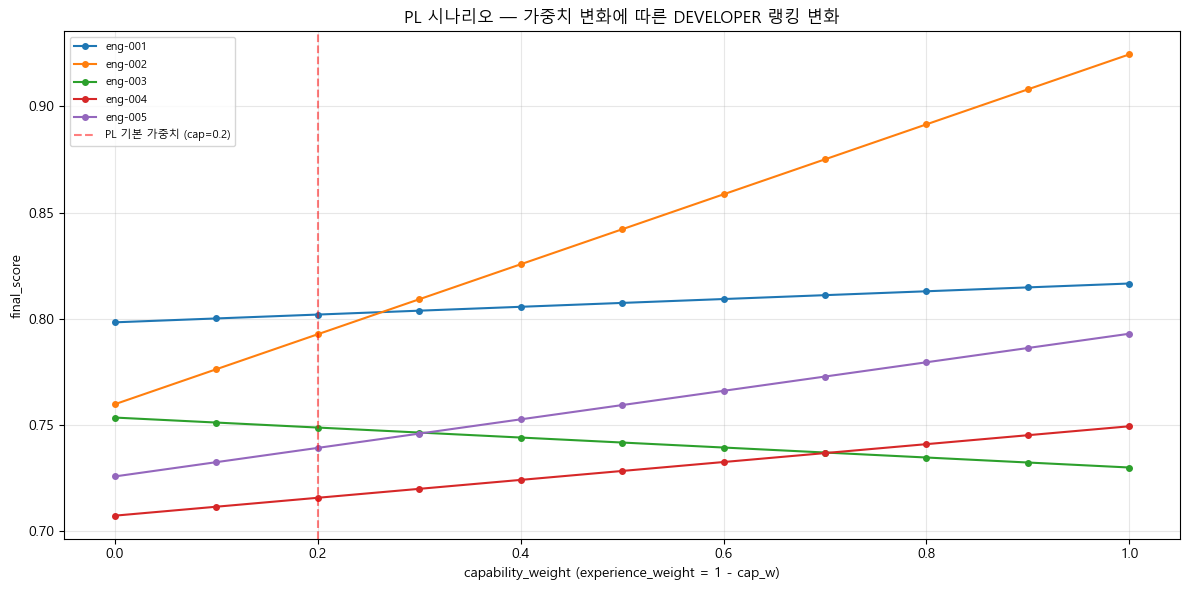

In [9]:
# PL 시나리오 가중치 변화 실험
pl_sc = scenarios[2]  # PL (경험 중심) + 제조업 리더십

cap_q = np.array(embeddings.embed_query(pl_sc["cap_query"]))
exp_q = np.array(embeddings.embed_query(pl_sc["exp_query"]))
cap_q = cap_q / np.linalg.norm(cap_q)
exp_q = exp_q / np.linalg.norm(exp_q)

cap_sims = cap_normed @ cap_q
exp_sims = exp_normed @ exp_q

# 가중치 0.0 ~ 1.0 변화 (cap_weight 기준, exp_weight = 1 - cap_weight)
weight_steps = np.arange(0.0, 1.05, 0.1)
engineer_ids = [p.engineer_id for p in profiles]

# 엔지니어별 점수 추적
score_traces = {eid: [] for eid in engineer_ids}

for cap_w in weight_steps:
    exp_w = 1.0 - cap_w
    final = cap_w * cap_sims + exp_w * exp_sims
    for i, eid in enumerate(engineer_ids):
        score_traces[eid].append(float(final[i]))

# 상위 5명만 그래프로
dev_ids = [p.engineer_id for p in profiles if p.engineer_role == "DEVELOPER"]

fig, ax = plt.subplots(figsize=(12, 6))
for eid in dev_ids:
    ax.plot(weight_steps, score_traces[eid], marker="o", markersize=4, label=eid)

ax.axvline(x=0.2, color="red", linestyle="--", alpha=0.5, label="PL 기본 가중치 (cap=0.2)")
ax.set_xlabel("capability_weight (experience_weight = 1 - cap_w)")
ax.set_ylabel("final_score")
ax.set_title(f"PL 시나리오 — 가중치 변화에 따른 DEVELOPER 랭킹 변화")
ax.legend(loc="best", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. 듀얼 벡터의 "차별화 능력" 정량화

핵심 질문: capability 유사도 순위와 experience 유사도 순위가 **얼마나 다른가?**
- 순위 상관계수(Spearman)가 낮을수록 → 두 벡터가 다른 관점을 제공 → 듀얼 분리 가치 높음
- 순위 상관계수가 높으면 → 한 벡터로 충분 → 듀얼 분리 의미 없음

In [11]:
from scipy.stats import spearmanr

print(f"{'시나리오':30s} {'Spearman r':>10s} {'p-value':>10s} {'해석'}")
print("-" * 70)

for sc in scenarios:
    cq = np.array(embeddings.embed_query(sc["cap_query"]))
    eq = np.array(embeddings.embed_query(sc["exp_query"]))
    cq = cq / np.linalg.norm(cq)
    eq = eq / np.linalg.norm(eq)

    cap_scores = cap_normed @ cq
    exp_scores = exp_normed @ eq

    r, p = spearmanr(cap_scores, exp_scores)

    if abs(r) < 0.3:
        interpretation = "독립적 (듀얼 가치 높음)"
    elif abs(r) < 0.7:
        interpretation = "중간 상관 (듀얼 보통)"
    else:
        interpretation = "높은 상관 (듀얼 효과 낮음)"

    print(f"{sc['name']:30s} {r:10.4f} {p:10.4f} {interpretation}")

시나리오                           Spearman r    p-value 해석
----------------------------------------------------------------------
Java/Spring 백엔드 + 제조업 ERP 경험       0.7833     0.0125 높은 상관 (듀얼 효과 낮음)
React 프론트엔드 + 차트 대시보드              0.4833     0.1875 중간 상관 (듀얼 보통)
PL (경험 중심) + 제조업 리더십               0.6667     0.0499 중간 상관 (듀얼 보통)
이커머스 물류 백엔드                        0.4667     0.2054 중간 상관 (듀얼 보통)
UX 디자이너 + 핀테크                      0.5333     0.1392 중간 상관 (듀얼 보통)


## 8. 시나리오별 cap/exp 스코어 분포 시각화

각 시나리오에서 9명 엔지니어의 capability_score(x축) vs experience_score(y축)를 scatter로 그려서
듀얼 벡터가 2차원 공간에서 후보를 어떻게 분리하는지 확인.

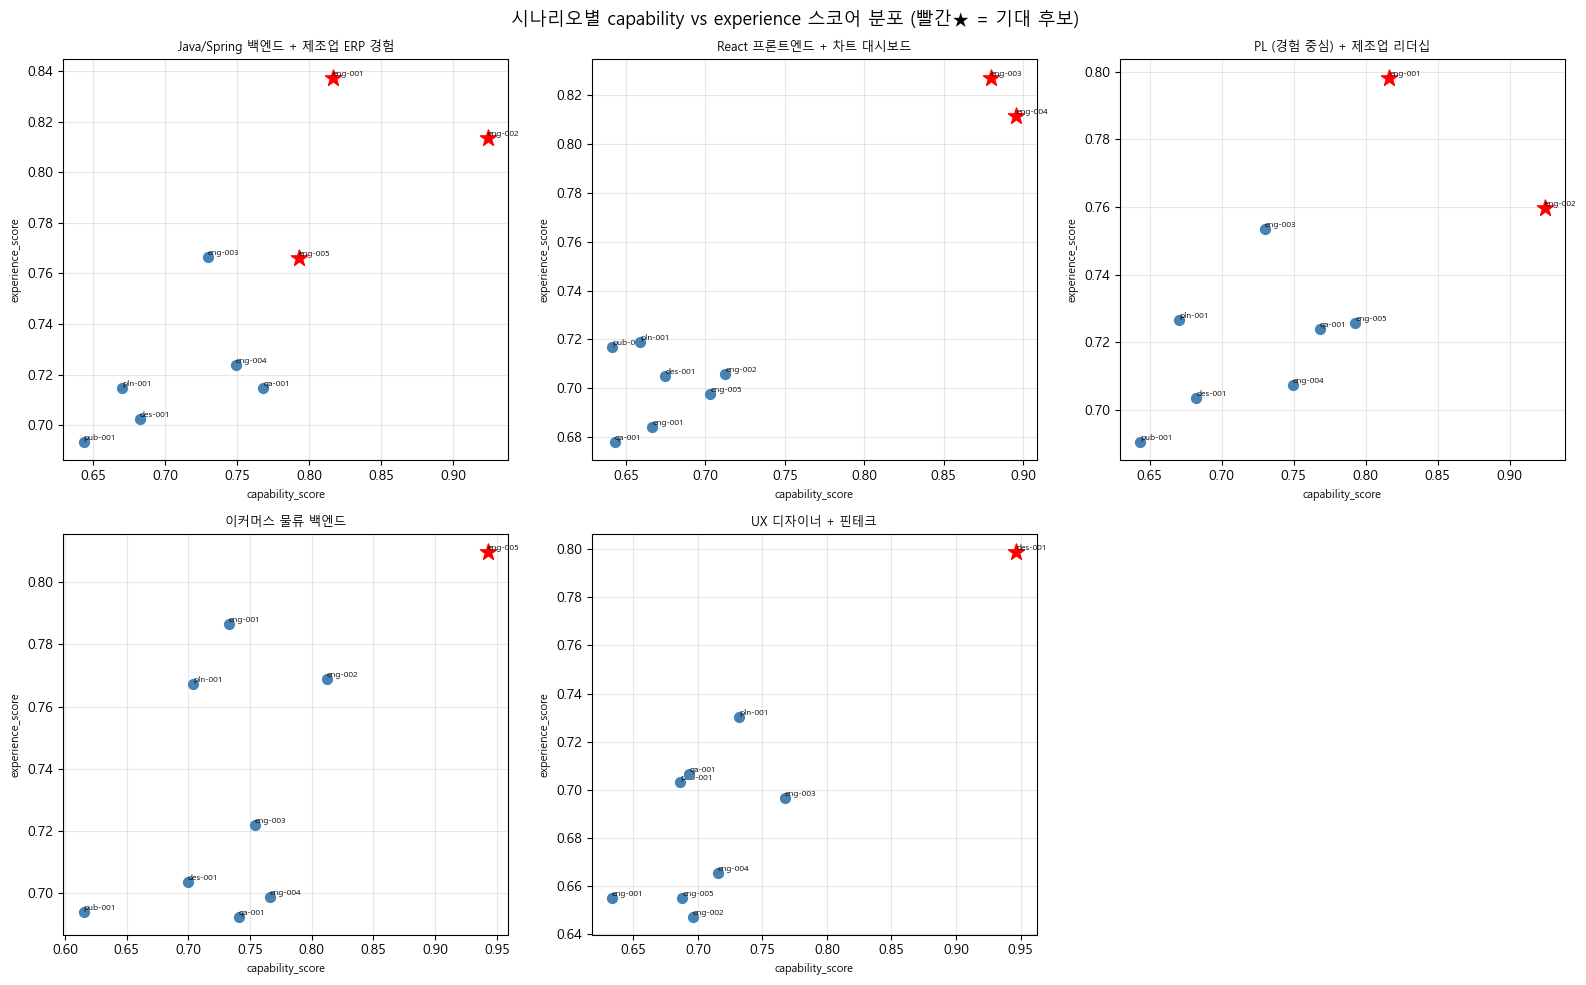

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, sc in enumerate(scenarios):
    ax = axes[idx]
    cq = np.array(embeddings.embed_query(sc["cap_query"]))
    eq = np.array(embeddings.embed_query(sc["exp_query"]))
    cq = cq / np.linalg.norm(cq)
    eq = eq / np.linalg.norm(eq)

    cap_scores = cap_normed @ cq
    exp_scores = exp_normed @ eq

    for i, p in enumerate(profiles):
        is_expected = p.engineer_id in sc["expected_top3"]
        color = "red" if is_expected else "steelblue"
        marker = "*" if is_expected else "o"
        size = 150 if is_expected else 50
        ax.scatter(cap_scores[i], exp_scores[i], c=color, marker=marker, s=size, zorder=3)
        ax.annotate(p.engineer_id, (cap_scores[i], exp_scores[i]),
                    fontsize=6, ha="left", va="bottom")

    ax.set_xlabel("capability_score", fontsize=8)
    ax.set_ylabel("experience_score", fontsize=8)
    ax.set_title(sc["name"], fontsize=9)
    ax.grid(True, alpha=0.3)

# 빈 subplot 숨기기
if len(scenarios) < len(axes):
    for j in range(len(scenarios), len(axes)):
        axes[j].set_visible(False)

fig.suptitle("시나리오별 capability vs experience 스코어 분포 (빨간★ = 기대 후보)", fontsize=13)
plt.tight_layout()
plt.show()